## Study of harmonic content for SSRL 10-1 grating monochromator
awojdyla@lbl.gov, March 2026

Notes (late Feb 2026):
+ M0 aperture reduced to 0.4 mrad
+ changed M0 to 1.20 and M1 to 2.25 deg
+ increased the simulations precision and max energy (spectra results series 78)

## Flux through an aperture

In [25]:
import numpy as np
import matplotlib.pyplot as plt 

import json

N_f = 475
E_list_eV = np.zeros(N_f)
full_flux_list_ph_ps_p01BW = np.zeros(N_f)
apertured_flux_list_ph_ps_p01BW = np.zeros(N_f)

for i_f in range(1, N_f) :
    #print(f'Processing file {i_f} of {N_f-1}')
    filename = f'../data/spectra-ssrl/ssrl_10_1-78_{i_f}.json'
    # Replace 'data.json' with the path to your file


    with open(filename, 'r') as file:
        data = json.load(file)

    E_eV = data['Output']['Set Value']
    xp_mrad = data['Output']['data'][0]
    xp_mrad = data['Output']['data'][0]
    yp_mrad = data['Output']['data'][1]
    flux_ph_ps_p01BW = data['Output']['data'][2]

    X,Y = np.meshgrid(xp_mrad, yp_mrad)
    flux_density_ph_ps_p01BW= np.array(flux_ph_ps_p01BW).reshape(len(yp_mrad), len(xp_mrad))

    mask_x = (X < 2.25) | (X > 2.75)
    mask_y = (Y > 0.4)
    flux_aperture_density_ph_ps_p01BW = flux_density_ph_ps_p01BW.copy()
    flux_aperture_density_ph_ps_p01BW[mask_x | mask_y] = 0

    dx_mrad = xp_mrad[1] - xp_mrad[0]
    dy_mrad = yp_mrad[1] - yp_mrad[0]

    full_flux_ph_ps_p01BW      = 2*np.sum(flux_density_ph_ps_p01BW) * dx_mrad * dy_mrad
    apertured_flux_ph_ps_p01BW = 2*np.sum(flux_aperture_density_ph_ps_p01BW) * dx_mrad * dy_mrad

    E_list_eV[i_f] = E_eV
    full_flux_list_ph_ps_p01BW[i_f] = full_flux_ph_ps_p01BW
    apertured_flux_list_ph_ps_p01BW[i_f] = apertured_flux_ph_ps_p01BW

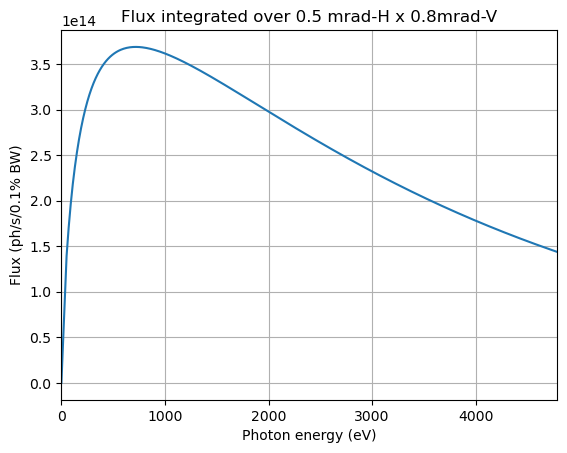

In [ ]:
plt.plot(E_list_eV, apertured_flux_list_ph_ps_p01BW, label='Full flux')
plt.xlabel('Photon energy (eV)')
plt.ylabel('Flux (ph/s/0.1% BW)')
plt.title('Flux integrated over 0.4 mrad-H x 0.8mrad-V')
plt.xlim(0,  np.max(E_list_eV))
plt.grid()
plt.show()

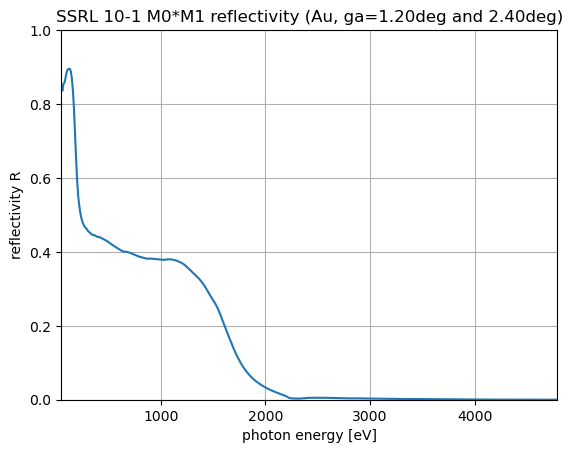

In [31]:
import xrt.backends.raycing.materials as rm
import matplotlib.pyplot as plt
import periodictable as pt
import numpy as np

rho = pt.Au.density
mat = rm.Material('Au',table='Henke',rho=rho)

E_min_eV = 50
E_max_eV = 1600

ga_rad = 1.05*np.pi/180

#N_i = 156
#energies_eV = np.linspace(E_min_eV, E_max_eV, N_i)
energies_eV = E_list_eV
energies_eV[energies_eV<50] = 50
N_i = N_f

R_M0 = np.zeros(N_i)
R_M1 = np.zeros(N_i)
ga_M0_rad = 1.20*np.pi/180
for i in np.arange(N_i):
    beamInDotNormal = np.cos(np.pi/2-ga_M0_rad)
    (rs,rp,c,d) = mat.get_amplitude(energies_eV[i],beamInDotNormal)
    R_M0[i] = 0.5*(np.abs(rs)**2+np.abs(rp)**2)

ga_M1_rad = 2.40*np.pi/180
for i in np.arange(N_i):
    beamInDotNormal = np.cos(np.pi/2-ga_M1_rad)
    (rs,rp,c,d) = mat.get_amplitude(energies_eV[i],beamInDotNormal)
    R_M1[i] = 0.5*(np.abs(rs)**2+np.abs(rp)**2)

plt.plot(energies_eV, R_M0*R_M1)
#plt.plot(energies_eV, Rs, energies_eV, Rp)
plt.xlabel('photon energy [eV]')
plt.ylabel('reflectivity R')
plt.title('SSRL 10-1 M0*M1 reflectivity (Au, ga=%1.2fdeg and %1.2fdeg)' %(ga_M0_rad*180/np.pi, ga_M1_rad*180/np.pi))
plt.xlim((np.min(energies_eV),np.max(energies_eV)))
plt.ylim((0,1))
plt.grid()
plt.show()


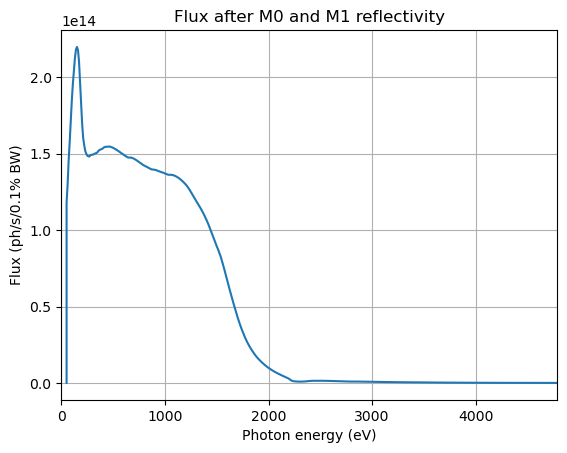

In [32]:
filtered_flux_list_ph_ps_p01BW = apertured_flux_list_ph_ps_p01BW * R_M0 * R_M1
plt.plot(energies_eV, filtered_flux_list_ph_ps_p01BW, label='Filtered flux')
plt.xlabel('Photon energy (eV)')
plt.ylabel('Flux (ph/s/0.1% BW)')
plt.title('Flux after M0 and M1 reflectivity')
plt.xlim(0,  np.max(E_list_eV))
plt.grid()
plt.show()

In [ ]:
from scipy.io import loadmat

# Load the MATLAB file
matlab_file_path = '../data/matlab-ssrl/HEG_a.mat'
matlab_data = loadmat(matlab_file_path)

dict_keys(['__header__', '__version__', '__globals__', 'Es_eV', 'cff', 'etas_blaze', 'g_lpm', 'thetas_rad'])


In [45]:
cff = matlab_data['cff'].flatten()
Em_eV = matlab_data['Es_eV'].flatten()
etas_blaze = matlab_data['etas_blaze'].flatten()  
g_lpm = matlab_data['g_lpm'].flatten()
thetas_rad = matlab_data['thetas_rad'].flatten()

In [46]:
csv_path = '../data/matlab-ssrl/SSRL_HEGa_M2.csv'
np.savetxt(
    csv_path,
    np.column_stack((Em_eV, thetas_rad)),
    delimiter=',',
    header='Em_eV,thetas_rad',
    comments=''
)
print(f'Saved {len(Em_eV)} rows to {csv_path}')

Saved 31 rows to ../data/matlab-ssrl/SSRL_HEGa_M2.csv


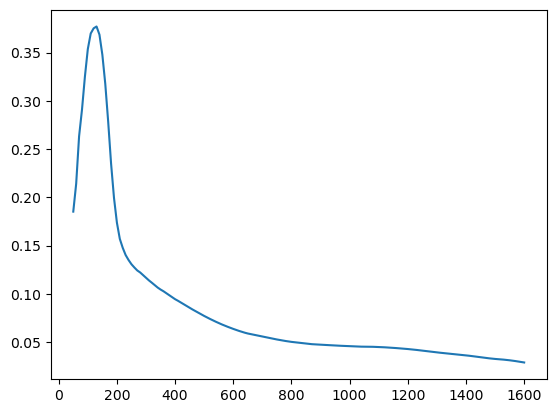

In [24]:
import matplotlib.pyplot as plt
import numpy as np
plt.plot(Em_eV, etas_blaze)
plt.show()

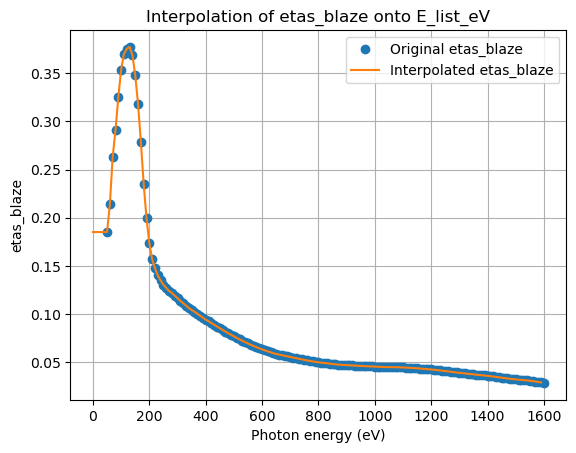

In [25]:
from scipy.interpolate import interp1d

# Interpolate etas_blaze onto E_list_eV
etas_blaze_interp = np.interp(E_list_eV, Em_eV, etas_blaze)
thetas_rad_interp = np.interp(E_list_eV, Em_eV, thetas_rad)

# Plot the interpolated data
plt.plot(Em_eV, etas_blaze, 'o', label='Original etas_blaze')
plt.plot(E_list_eV, etas_blaze_interp, '-', label='Interpolated etas_blaze')
plt.xlabel('Photon energy (eV)')
plt.ylabel('etas_blaze')
plt.legend()
plt.title('Interpolation of etas_blaze onto E_list_eV')
plt.grid()
plt.show()

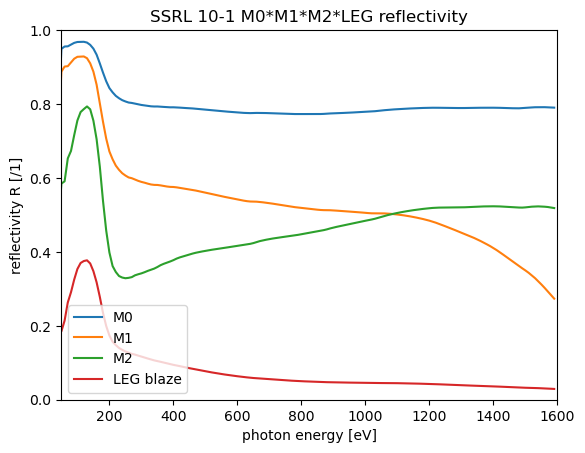

In [26]:
R_M0 = np.zeros(E_list_eV.shape)
R_M1 = np.zeros(E_list_eV.shape)

ga_M0_rad = 1.05*np.pi/180
for i in np.arange(N_i):
    if i!= 0:
        beamInDotNormal = np.cos(np.pi/2-ga_M0_rad)
        (rs,rp,c,d) = mat.get_amplitude(energies_eV[i],beamInDotNormal)
        R_M0[i] = 0.5*(np.abs(rs)**2+np.abs(rp)**2)

ga_M1_rad = 2.40*np.pi/180
for i in np.arange(N_i):
    if i!= 0:
        beamInDotNormal = np.cos(np.pi/2-ga_M1_rad)
        (rs,rp,c,d) = mat.get_amplitude(energies_eV[i],beamInDotNormal)
        R_M1[i] = 0.5*(np.abs(rs)**2+np.abs(rp)**2)

R_M2 = np.zeros(E_list_eV.shape)
for i in np.arange(E_list_eV.shape[0]):
    if i!= 0:
        beamInDotNormal = np.cos(thetas_rad_interp[i])
        (rs,rp,c,d) = mat.get_amplitude(E_list_eV[i],beamInDotNormal)
        R_M2[i] = 0.5*(np.abs(rs)**2+np.abs(rp)**2)


total_efficiency = R_M0*R_M1*R_M2*etas_blaze_interp
plt.plot(E_list_eV, R_M0, E_list_eV, R_M1, E_list_eV, R_M2, E_list_eV, etas_blaze_interp)
#plt.plot(energies_eV, Rs, energies_eV, Rp)
plt.xlabel('photon energy [eV]')
plt.ylabel('reflectivity R [/1]')
plt.legend(['M0', 'M1', 'M2', 'LEG blaze'])
plt.title('SSRL 10-1 M0*M1*M2*LEG reflectivity')
plt.xlim((np.min(energies_eV),np.max(energies_eV)))
plt.ylim((0,1))
plt.show()

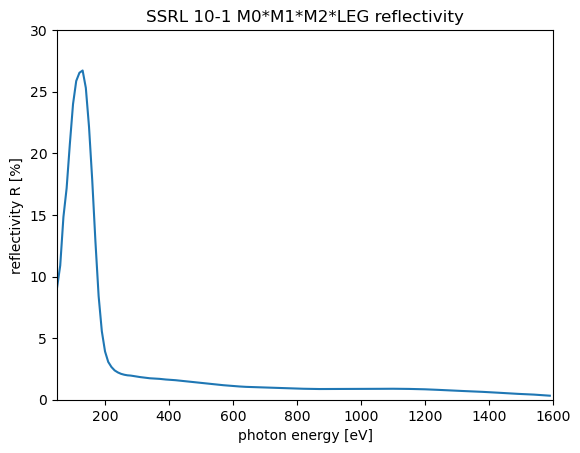

In [27]:
total_efficiency = R_M0*R_M1*R_M2*etas_blaze_interp
plt.plot(E_list_eV, total_efficiency*100)
#plt.plot(energies_eV, Rs, energies_eV, Rp)
plt.xlabel('photon energy [eV]')
plt.ylabel('reflectivity R [%]')
plt.title('SSRL 10-1 M0*M1*M2*LEG reflectivity')
plt.xlim((np.min(energies_eV),np.max(energies_eV)))
plt.ylim((0,30))

plt.show()

In [28]:
frac = 1/np.sqrt(E_list_eV/50)
frac_e = frac*0.8

frac_flux_ph_s_01pcBW = np.zeros(E_list_eV.shape)
transmitted_flux_ph_s = np.zeros(E_list_eV.shape)
resolved_flux_ph_s = np.zeros(E_list_eV.shape)
for i_e in range(E_list_eV.shape[0]):
    frac_flux_ph_s_01pcBW[i_e] = np.interp(frac_e[i_e], 2*Y[:,0], flux_cumsum_ph_ps_p01BW[:,i_e])
    resolved_flux_ph_s[i_e]  = frac_flux_ph_s_01pcBW[i_e]*0.1
    transmitted_flux_ph_s[i_e] = resolved_flux_ph_s[i_e]*total_efficiency[i_e]

/var/folders/hr/17npbd3151g552w6q43kqpr80000gn/T/ipykernel_46243/3004110217.py:1: RuntimeWarning: divide by zero encountered in divide
  frac = 1/np.sqrt(E_list_eV/50)


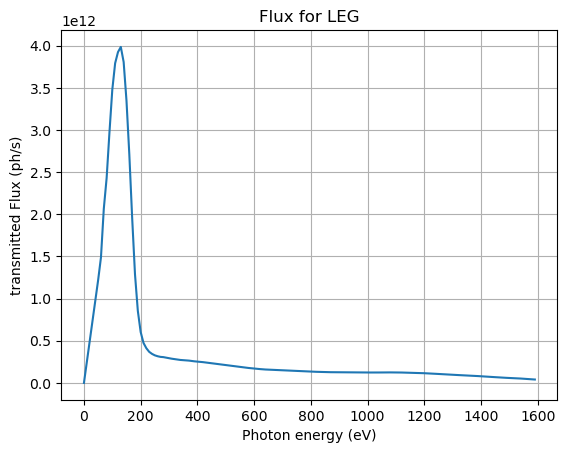

In [29]:
plt.plot(E_list_eV, transmitted_flux_ph_s, label='Full flux')
plt.xlabel('Photon energy (eV)')
plt.ylabel('transmitted Flux (ph/s)')
plt.title('Flux for LEG')
plt.grid()

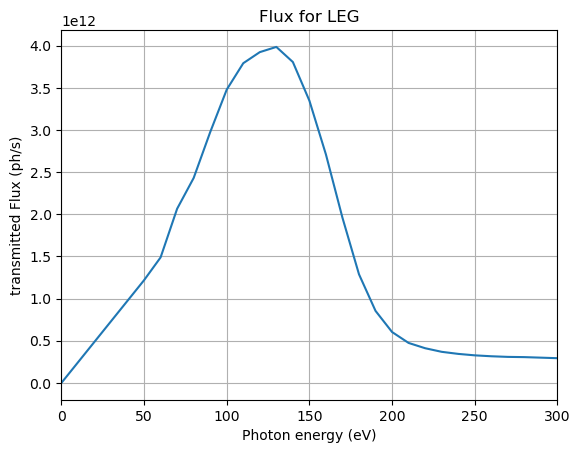

In [30]:
plt.plot(E_list_eV, transmitted_flux_ph_s, label='Full flux')
plt.xlabel('Photon energy (eV)')
plt.ylabel('transmitted Flux (ph/s)')
plt.title('Flux for LEG')
plt.xlim((0, 300))
plt.grid()

## Harmonics

In [46]:
from scipy.io import loadmat

# Load the MATLAB file
matlab_file_path = '../data/matlab-ssrl/LEG_harm_a.mat'
matlab_data = loadmat(matlab_file_path)

# Display the keys in the loaded MATLAB file
print(matlab_data.keys())


cff = matlab_data['cff'].flatten()
Em_eV = matlab_data['Es_eV'].flatten()
etas_harm1 = matlab_data['eta_harm1'].flatten()  
etas_harm2 = matlab_data['eta_harm2'].flatten()  
etas_harm3 = matlab_data['eta_harm3'].flatten()  
g_lpm = matlab_data['g_lpm'].flatten()
thetas_rad = matlab_data['thetas_rad'].flatten()

from scipy.interpolate import interp1d

# Interpolate etas_blaze onto E_list_eV
etas_harm1_interp = np.interp(E_list_eV, Em_eV, etas_harm1)
etas_harm2_interp = np.interp(E_list_eV, Em_eV, etas_harm2)
etas_harm3_interp = np.interp(E_list_eV, Em_eV, etas_harm3)
thetas_rad_interp = np.interp(E_list_eV, Em_eV, thetas_rad)

dict_keys(['__header__', '__version__', '__globals__', 'Es_eV', 'cff', 'eta_harm1', 'eta_harm2', 'eta_harm3', 'g_lpm', 'thetas_rad'])


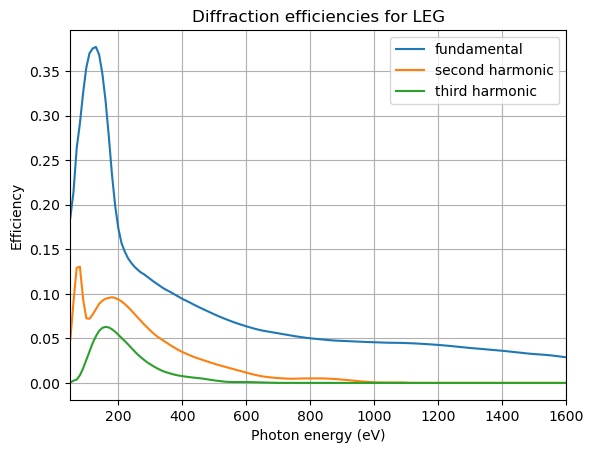

In [50]:
plt.plot(E_list_eV, etas_harm1_interp)
plt.plot(E_list_eV, etas_harm2_interp)
plt.plot(E_list_eV, etas_harm3_interp)
plt.xlabel('Photon energy (eV)')
plt.ylabel('Efficiency')
plt.title('Diffraction efficiencies for LEG')
plt.legend(['fundamental', 'second harmonic', 'third harmonic'])
plt.xlim((50, 1600))
plt.grid()

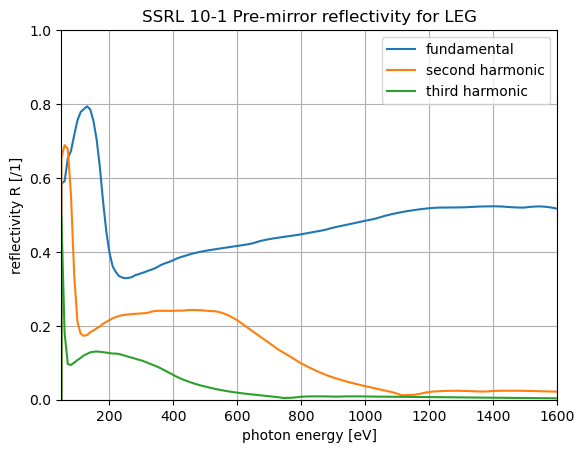

In [53]:
R_M2_1 = np.zeros(E_list_eV.shape)
R_M2_2 = np.zeros(E_list_eV.shape)
R_M2_3 = np.zeros(E_list_eV.shape)
for i in np.arange(E_list_eV.shape[0]):
    if i!= 0:
        beamInDotNormal = np.cos(thetas_rad_interp[i])
        (rs,rp,c,d) = mat.get_amplitude(E_list_eV[i],beamInDotNormal)
        R_M2_1[i] = 0.5*(np.abs(rs)**2+np.abs(rp)**2)
        (rs,rp,c,d) = mat.get_amplitude(E_list_eV[i]*2,beamInDotNormal)
        R_M2_2[i] = 0.5*(np.abs(rs)**2+np.abs(rp)**2)
        (rs,rp,c,d) = mat.get_amplitude(E_list_eV[i]*3,beamInDotNormal)
        R_M2_3[i] = 0.5*(np.abs(rs)**2+np.abs(rp)**2)

plt.plot(E_list_eV, R_M2_1, E_list_eV, R_M2_2, E_list_eV, R_M2_3)
#plt.plot(energies_eV, Rs, energies_eV, Rp)
plt.xlabel('photon energy [eV]')
plt.ylabel('reflectivity R [/1]')
plt.legend(['fundamental', 'second harmonic', 'third harmonic'])
plt.title('SSRL 10-1 Pre-mirror reflectivity for LEG')
plt.xlim((50,1600))
plt.ylim((0,1))
plt.grid()
plt.show()

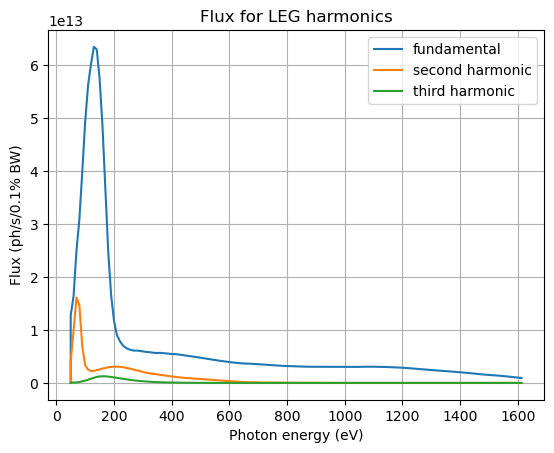

In [51]:
flux_H1_list = []
flux_H2_list = []
flux_H3_list = []
for i in np.arange(E_list_eV.shape[0]//3):
    flux_H1_list.append(filtered_flux_list_ph_ps_p01BW[i]  *R_M2_1[i]*etas_harm1_interp[i])
    flux_H2_list.append(filtered_flux_list_ph_ps_p01BW[2*i]*R_M2_2[i]*etas_harm2_interp[i])
    flux_H3_list.append(filtered_flux_list_ph_ps_p01BW[3*i]*R_M2_3[i]*etas_harm3_interp[i])

plt.plot(E_list_eV[:len(flux_H1_list)], flux_H1_list, label='H1')
plt.plot(E_list_eV[:len(flux_H2_list)], flux_H2_list, label='H2')
plt.plot(E_list_eV[:len(flux_H3_list)], flux_H3_list, label='H3')
plt.xlabel('Photon energy (eV)')
plt.ylabel('Flux (ph/s/0.1% BW)')
plt.title('Flux for LEG harmonics')
plt.legend(['fundamental', 'second harmonic', 'third harmonic'])
#plt.xlim((0, 300))
plt.grid()


/var/folders/hr/17npbd3151g552w6q43kqpr80000gn/T/ipykernel_89657/4130030963.py:1: RuntimeWarning: invalid value encountered in divide
  harmonic_contamination_harm2 = np.array(flux_H2_list)/np.array(flux_H1_list)
/var/folders/hr/17npbd3151g552w6q43kqpr80000gn/T/ipykernel_89657/4130030963.py:2: RuntimeWarning: invalid value encountered in divide
  harmonic_contamination_harm3 = np.array(flux_H3_list)/np.array(flux_H1_list)


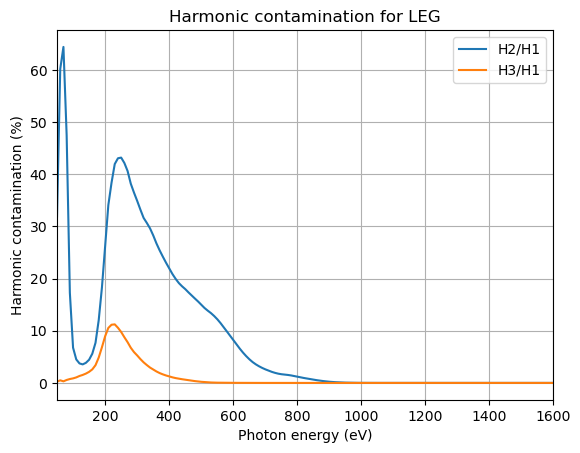

In [55]:
harmonic_contamination_harm2 = np.array(flux_H2_list)/np.array(flux_H1_list)
harmonic_contamination_harm3 = np.array(flux_H3_list)/np.array(flux_H1_list)

plt.plot(E_list_eV[:len(flux_H1_list)], harmonic_contamination_harm2*100, label='H2/H1')
plt.plot(E_list_eV[:len(flux_H1_list)], harmonic_contamination_harm3*100, label='H3/H1')
plt.xlabel('Photon energy (eV)')
plt.ylabel('Harmonic contamination (%)')
plt.title('Harmonic contamination for LEG')
plt.legend(['H2/H1', 'H3/H1'])
plt.xlim((50, 1600))
plt.grid()  

/var/folders/hr/17npbd3151g552w6q43kqpr80000gn/T/ipykernel_89657/1476821442.py:1: RuntimeWarning: invalid value encountered in divide
  harmonic_contamination_harm2 = np.array(flux_H2_list)/np.array(flux_H1_list)
/var/folders/hr/17npbd3151g552w6q43kqpr80000gn/T/ipykernel_89657/1476821442.py:2: RuntimeWarning: invalid value encountered in divide
  harmonic_contamination_harm3 = np.array(flux_H3_list)/np.array(flux_H1_list)


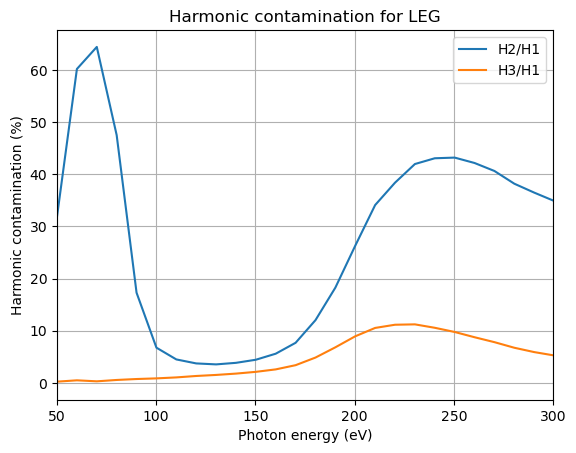

In [56]:
harmonic_contamination_harm2 = np.array(flux_H2_list)/np.array(flux_H1_list)
harmonic_contamination_harm3 = np.array(flux_H3_list)/np.array(flux_H1_list)

plt.plot(E_list_eV[:len(flux_H1_list)], harmonic_contamination_harm2*100, label='H2/H1')
plt.plot(E_list_eV[:len(flux_H1_list)], harmonic_contamination_harm3*100, label='H3/H1')
plt.xlabel('Photon energy (eV)')
plt.ylabel('Harmonic contamination (%)')
plt.title('Harmonic contamination for LEG')
plt.legend(['H2/H1', 'H3/H1'])
plt.xlim((50, 300))
plt.grid()  

In [62]:
from scipy.io import loadmat

# Load the MATLAB file
matlab_file_path = '../data/matlab-ssrl/HEG_harm_a.mat'
matlab_data = loadmat(matlab_file_path)

# Display the keys in the loaded MATLAB file
#print(matlab_data.keys())


cff = matlab_data['cff'].flatten()
Em_eV = matlab_data['Es_eV'].flatten()
etas_harm1 = matlab_data['eta_harm1'].flatten()  
etas_harm2 = matlab_data['eta_harm2'].flatten()  
etas_harm3 = matlab_data['eta_harm3'].flatten()  
g_lpm = matlab_data['g_lpm'].flatten()
thetas_rad = matlab_data['thetas_rad'].flatten()

from scipy.interpolate import interp1d

# Interpolate etas_blaze onto E_list_eV
etas_harm1_interp = np.interp(E_list_eV, Em_eV, etas_harm1)
etas_harm2_interp = np.interp(E_list_eV, Em_eV, etas_harm2)
etas_harm3_interp = np.interp(E_list_eV, Em_eV, etas_harm3)
thetas_rad_interp = np.interp(E_list_eV, Em_eV, thetas_rad)

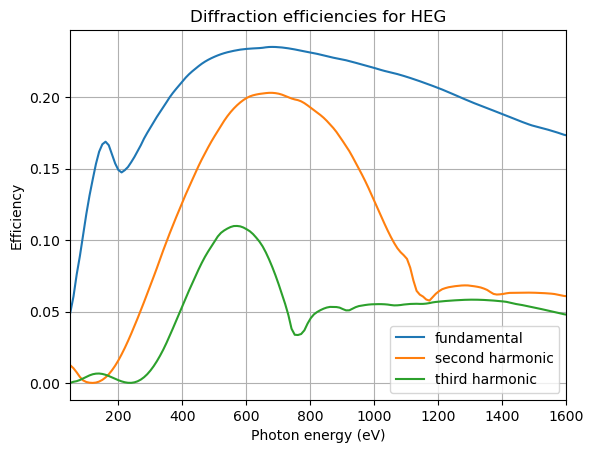

In [63]:
plt.plot(E_list_eV, etas_harm1_interp)
plt.plot(E_list_eV, etas_harm2_interp)
plt.plot(E_list_eV, etas_harm3_interp)
plt.xlabel('Photon energy (eV)')
plt.ylabel('Efficiency')
plt.title('Diffraction efficiencies for HEG')
plt.legend(['fundamental', 'second harmonic', 'third harmonic'])
plt.xlim((50, 1600))
plt.grid()

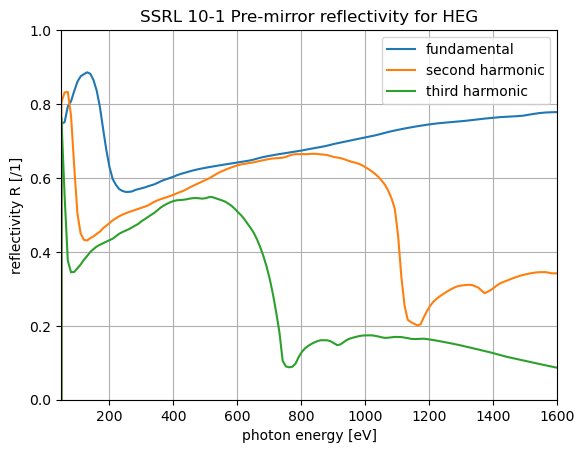

In [64]:
R_M2_1 = np.zeros(E_list_eV.shape)
R_M2_2 = np.zeros(E_list_eV.shape)
R_M2_3 = np.zeros(E_list_eV.shape)
for i in np.arange(E_list_eV.shape[0]):
    if i!= 0:
        beamInDotNormal = np.cos(thetas_rad_interp[i])
        (rs,rp,c,d) = mat.get_amplitude(E_list_eV[i],beamInDotNormal)
        R_M2_1[i] = 0.5*(np.abs(rs)**2+np.abs(rp)**2)
        (rs,rp,c,d) = mat.get_amplitude(E_list_eV[i]*2,beamInDotNormal)
        R_M2_2[i] = 0.5*(np.abs(rs)**2+np.abs(rp)**2)
        (rs,rp,c,d) = mat.get_amplitude(E_list_eV[i]*3,beamInDotNormal)
        R_M2_3[i] = 0.5*(np.abs(rs)**2+np.abs(rp)**2)

plt.plot(E_list_eV, R_M2_1, E_list_eV, R_M2_2, E_list_eV, R_M2_3)
#plt.plot(energies_eV, Rs, energies_eV, Rp)
plt.xlabel('photon energy [eV]')
plt.ylabel('reflectivity R [/1]')
plt.legend(['fundamental', 'second harmonic', 'third harmonic'])
plt.title('SSRL 10-1 Pre-mirror reflectivity for HEG')
plt.xlim((50,1600))
plt.ylim((0,1))
plt.grid()
plt.show()

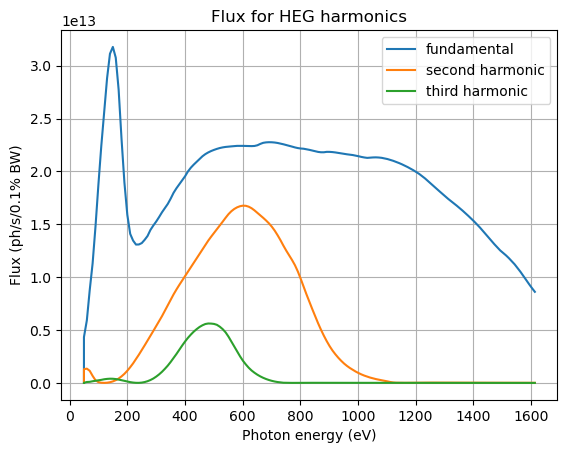

In [65]:
flux_H1_list = []
flux_H2_list = []
flux_H3_list = []
for i in np.arange(E_list_eV.shape[0]//3):
    flux_H1_list.append(filtered_flux_list_ph_ps_p01BW[i]  *R_M2_1[i]*etas_harm1_interp[i])
    flux_H2_list.append(filtered_flux_list_ph_ps_p01BW[2*i]*R_M2_2[i]*etas_harm2_interp[i])
    flux_H3_list.append(filtered_flux_list_ph_ps_p01BW[3*i]*R_M2_3[i]*etas_harm3_interp[i])

plt.plot(E_list_eV[:len(flux_H1_list)], flux_H1_list, label='H1')
plt.plot(E_list_eV[:len(flux_H2_list)], flux_H2_list, label='H2')
plt.plot(E_list_eV[:len(flux_H3_list)], flux_H3_list, label='H3')
plt.xlabel('Photon energy (eV)')
plt.ylabel('Flux (ph/s/0.1% BW)')
plt.title('Flux for HEG harmonics')
plt.legend(['fundamental', 'second harmonic', 'third harmonic'])
#plt.xlim((0, 300))
plt.grid()


/var/folders/hr/17npbd3151g552w6q43kqpr80000gn/T/ipykernel_89657/3234909112.py:1: RuntimeWarning: invalid value encountered in divide
  harmonic_contamination_harm2 = np.array(flux_H2_list)/np.array(flux_H1_list)
/var/folders/hr/17npbd3151g552w6q43kqpr80000gn/T/ipykernel_89657/3234909112.py:2: RuntimeWarning: invalid value encountered in divide
  harmonic_contamination_harm3 = np.array(flux_H3_list)/np.array(flux_H1_list)


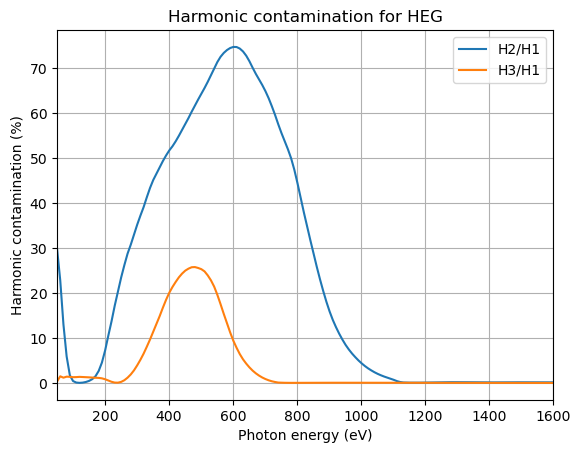

In [67]:
harmonic_contamination_harm2 = np.array(flux_H2_list)/np.array(flux_H1_list)
harmonic_contamination_harm3 = np.array(flux_H3_list)/np.array(flux_H1_list)

plt.plot(E_list_eV[:len(flux_H1_list)], harmonic_contamination_harm2*100, label='H2/H1')
plt.plot(E_list_eV[:len(flux_H1_list)], harmonic_contamination_harm3*100, label='H3/H1')
plt.xlabel('Photon energy (eV)')
plt.ylabel('Harmonic contamination (%)')
plt.title('Harmonic contamination for HEG')
plt.legend(['H2/H1', 'H3/H1'])
plt.xlim((50, 1600))
plt.grid()  